# 📈 Сравнение методов PEFT — анализ результатов

В этом ноутбуке мы визуализируем и анализируем результаты четырёх экспериментов:

| Метод | Суть |
|-------|------|
| **Full Fine-Tuning** | Все параметры обучаются — верхняя граница качества |
| **LoRA** | Низкоранговое разложение матриц внимания |
| **Adapter** | Bottleneck-слои внутри трансформерных блоков |
| **Prefix Tuning** | Обучаемые виртуальные токены |

**Главный вопрос:** можно ли обучать <1% параметров и получить результат не хуже полного файнтюнинга?

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

# ── Тёмная тема в стиле W&B ──────────────────────────────────────────
BG       = '#0f0f0f'
BG_PANEL = '#1a1a2e'
GRID     = '#2a2a3e'
TEXT     = '#e0e0e0'
TEXT_DIM = '#888888'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'axes.grid':         True,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       TEXT_DIM,
    'ytick.color':       TEXT_DIM,
    'text.color':        TEXT,
    'legend.facecolor':  BG_PANEL,
    'legend.edgecolor':  GRID,
    'legend.labelcolor': TEXT,
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
})

# ── Фирменные цвета для каждого метода ───────────────────────────────
METHOD_COLORS = {
    'LoRA':             '#4cc9f0',   # голубой
    'Adapter':          '#7bed9f',   # зелёный
    'Prefix Tuning':    '#ff6b6b',   # красный
    'Full Fine-Tuning': '#ffa502',   # оранжевый
}
CLASS_COLORS = {'negative': '#ff6b6b', 'neutral': '#a8a8b3', 'positive': '#7bed9f'}

print('Готово — тёмная тема загружена!')

Готово — тёмная тема загружена!


## 1. Загрузка данных обучения

Из `trainer_state.json` извлекаем историю обучения — train loss по шагам и eval метрики по чекпоинтам.

In [5]:
# Пути к trainer_state.json для каждого метода
state_paths = {
    'LoRA':             '../experiments/lora/checkpoint-2400/trainer_state.json',
    'Adapter':          '../experiments/adapter/checkpoint-1645/trainer_state.json',
    'Prefix Tuning':    '../experiments/prefix_tuning/checkpoint-2200/trainer_state.json',
    'Full Fine-Tuning': '../experiments/full_finetune/checkpoint-1800/trainer_state.json',
}

result_paths = {
    'LoRA':             '../experiments/lora/test_results.json',
    'Adapter':          '../experiments/adapter/test_results.json',
    'Prefix Tuning':    '../experiments/prefix_tuning/test_results.json',
    'Full Fine-Tuning': '../experiments/full_finetune/test_results.json',
}

trainable_params = {
    'LoRA':             592131,
    'Adapter':          1200000,
    'Prefix Tuning':    370947,
    'Full Fine-Tuning': 178447878,
}

# Загружаем все данные
states  = {}
results = {}

for method in state_paths:
    with open(state_paths[method],  encoding='utf-8') as f:
        states[method] = json.load(f)
    with open(result_paths[method], encoding='utf-8') as f:
        results[method] = json.load(f)

def parse_history(state):
    """Разделяем лог на train-записи и eval-записи."""
    train_log = [e for e in state['log_history'] if 'loss' in e and 'eval_loss' not in e]
    eval_log  = [e for e in state['log_history'] if 'eval_loss' in e]
    return train_log, eval_log

print('Данные загружены:')
for m in states:
    tl, el = parse_history(states[m])
    print(f'  {m:20}: {len(tl)} train записей, {len(el)} eval записей, '
          f'best F1={results[m]["f1_weighted"]:.4f}')

Данные загружены:
  LoRA                : 48 train записей, 12 eval записей, best F1=0.6838
  Adapter             : 32 train записей, 8 eval записей, best F1=0.7078
  Prefix Tuning       : 44 train записей, 11 eval записей, best F1=0.5926
  Full Fine-Tuning    : 36 train записей, 9 eval записей, best F1=0.7013


## 2. Кривые обучения — Train Loss

Train loss показывает как быстро модель обучается. Все методы начинают с одинакового уровня (~1.1 для 3 классов = log(3)), но скорость и глубина снижения отличаются. Применяем сглаживание Гаусса для читаемости — как это делает W&B.

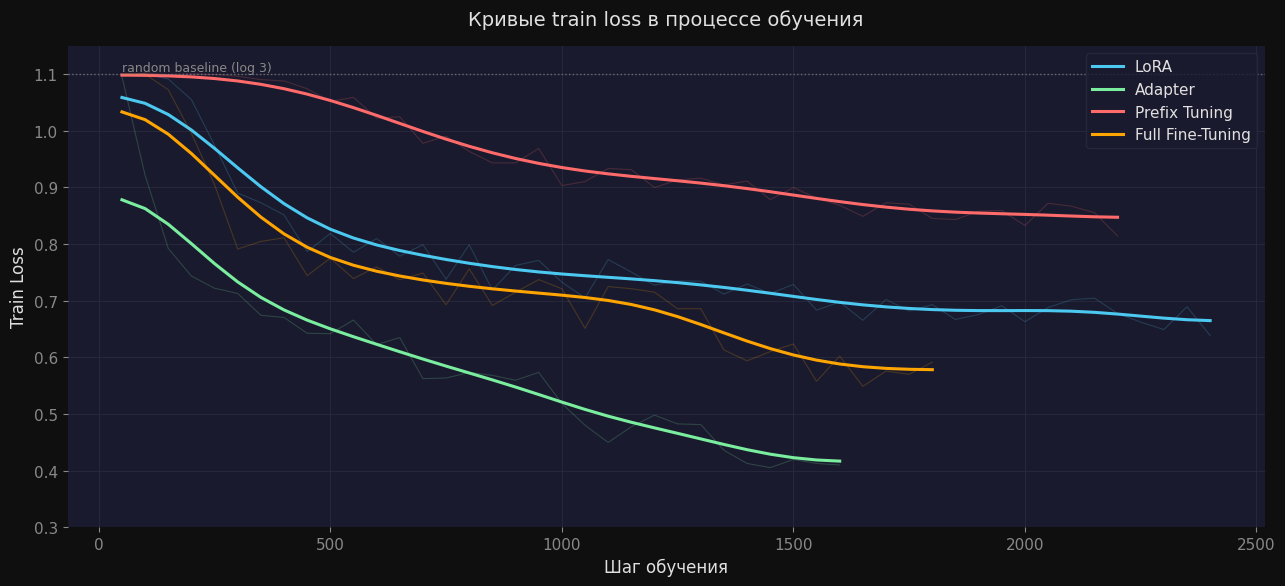

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)

for method, color in METHOD_COLORS.items():
    train_log, _ = parse_history(states[method])
    steps  = [e['step']  for e in train_log]
    losses = [e['loss']  for e in train_log]

    # Сырые данные — тонкая прозрачная линия
    ax.plot(steps, losses, color=color, alpha=0.2, linewidth=0.8)
    # Сглаженная кривая — основная линия
    smooth = gaussian_filter1d(losses, sigma=3)
    ax.plot(steps, smooth, color=color, linewidth=2.2, label=method)

ax.set_xlabel('Шаг обучения', fontsize=12)
ax.set_ylabel('Train Loss', fontsize=12)
ax.set_title('Кривые train loss в процессе обучения', fontsize=14, pad=15, color=TEXT)
ax.legend(loc='upper right', framealpha=0.8)
ax.set_ylim(0.3, 1.15)

# Горизонтальная линия — random baseline (log(3) ≈ 1.099)
ax.axhline(y=1.099, color=TEXT_DIM, linestyle=':', linewidth=1, alpha=0.7)
ax.text(50, 1.105, 'random baseline (log 3)', color=TEXT_DIM, fontsize=9)

plt.tight_layout()
plt.savefig('../experiments/plot_train_loss.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Вывод:** Adapter снижает loss быстрее всего и достигает наименьшего значения (~0.41). Full Fine-Tuning тоже снижается агрессивно, но с большими всплесками grad_norm. LoRA и Prefix Tuning снижаются медленнее — это согласуется с их меньшим числом обучаемых параметров.

## 3. Кривые качества на валидации — Eval F1

Eval F1 — это то, что нас реально интересует. Строим кривые по чекпоинтам и отмечаем лучшую точку каждого метода.

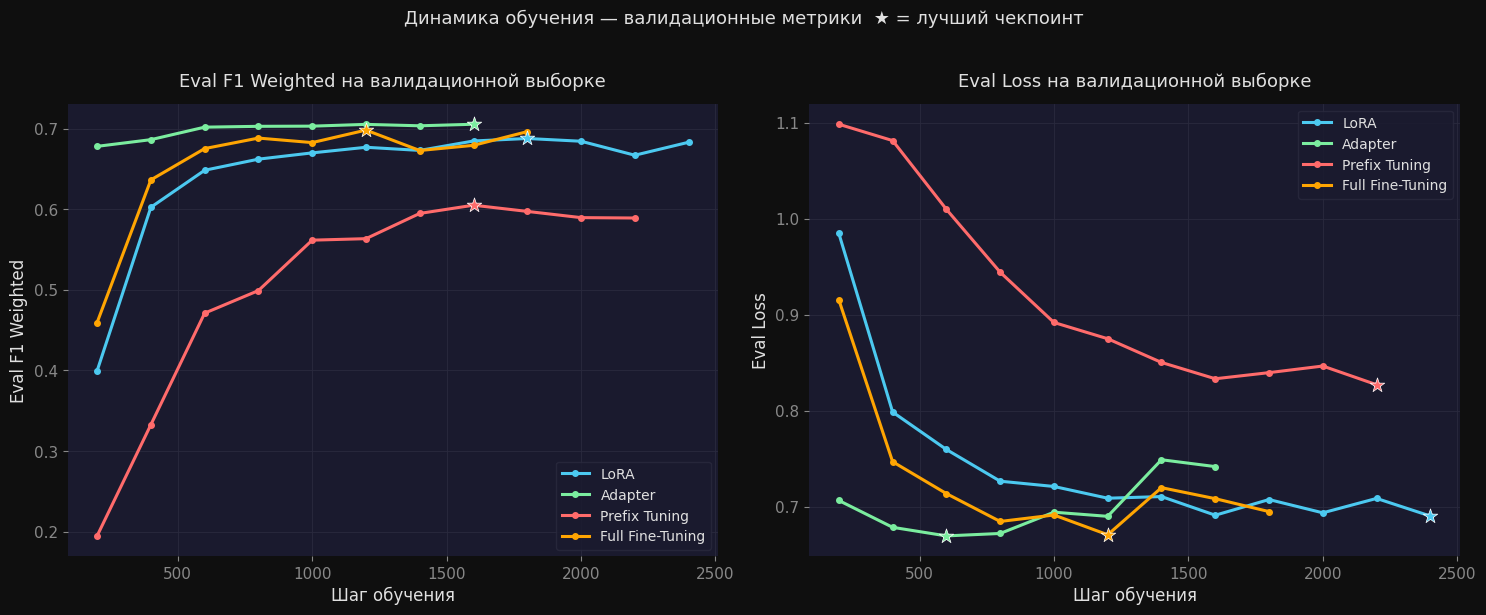

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)

for ax_idx, metric_key in enumerate(['eval_f1_weighted', 'eval_loss']):
    ax = axes[ax_idx]
    label = 'Eval F1 Weighted' if metric_key == 'eval_f1_weighted' else 'Eval Loss'

    for method, color in METHOD_COLORS.items():
        _, eval_log = parse_history(states[method])
        steps   = [e['step']       for e in eval_log]
        values  = [e[metric_key]   for e in eval_log]

        ax.plot(steps, values, color=color, linewidth=2.2,
                marker='o', markersize=4, label=method)

        # Отмечаем лучшую точку
        best_idx = np.argmax(values) if metric_key == 'eval_f1_weighted' else np.argmin(values)
        ax.scatter(steps[best_idx], values[best_idx],
                   color=color, s=120, zorder=5,
                   marker='*', edgecolors='white', linewidth=0.5)

    ax.set_xlabel('Шаг обучения', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(label + ' на валидационной выборке', fontsize=13, pad=12, color=TEXT)
    ax.legend(loc='lower right' if metric_key == 'eval_f1_weighted' else 'upper right',
              framealpha=0.8, fontsize=10)

plt.suptitle('Динамика обучения — валидационные метрики  ★ = лучший чекпоинт',
             fontsize=13, y=1.02, color=TEXT)
plt.tight_layout()
plt.savefig('../experiments/plot_eval_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Вывод:** Adapter достигает плато позже всех (~эпоха 3-4) и показывает наилучший финальный F1. LoRA и Full Fine-Tuning останавливаются раньше — early stopping сработал на эпохе ~1.8. Prefix Tuning всё ещё растёт в момент остановки, но заметно медленнее остальных.

## 4. Итоговое сравнение на тестовой выборке

Финальные метрики на тестовой выборке — то, что идёт в таблицу результатов.

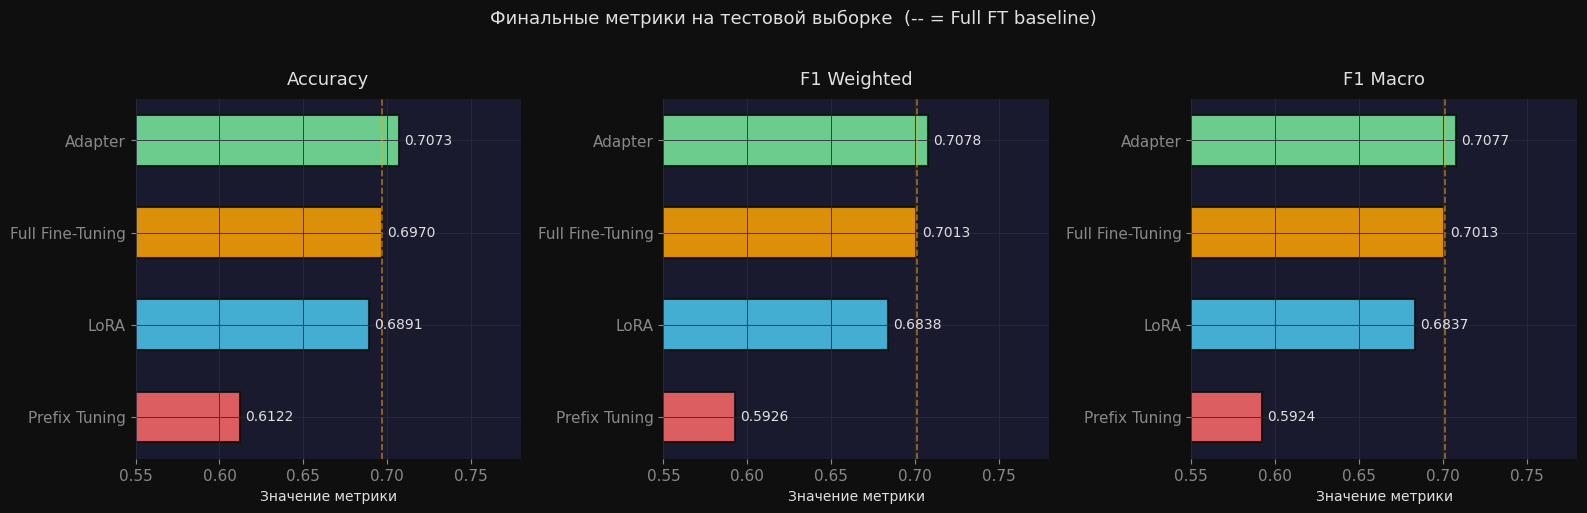

In [8]:
methods_sorted = sorted(METHOD_COLORS.keys(), key=lambda m: results[m]['f1_weighted'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

metrics = [
    ('accuracy',    'Accuracy'),
    ('f1_weighted', 'F1 Weighted'),
    ('f1_macro',    'F1 Macro'),
]

for ax, (key, label) in zip(axes, metrics):
    values = [results[m][key] for m in methods_sorted]
    colors = [METHOD_COLORS[m] for m in methods_sorted]
    bars   = ax.barh(methods_sorted, values, color=colors,
                     alpha=0.85, edgecolor=BG, linewidth=1.5, height=0.55)

    # Подписи значений
    for bar, val in zip(bars, values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=10, color=TEXT)

    # Вертикальная линия — Full Fine-Tuning baseline
    baseline = results['Full Fine-Tuning'][key]
    ax.axvline(x=baseline, color=METHOD_COLORS['Full Fine-Tuning'],
               linestyle='--', linewidth=1.2, alpha=0.6)

    ax.set_title(label, fontsize=13, pad=10, color=TEXT)
    ax.set_xlim(0.55, 0.78)
    ax.set_xlabel('Значение метрики', fontsize=10)

plt.suptitle('Финальные метрики на тестовой выборке  (-- = Full FT baseline)',
             fontsize=13, y=1.02, color=TEXT)
plt.tight_layout()
plt.savefig('../experiments/plot_final_metrics.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Trade-off: качество vs параметры

Главный график исследования — показывает насколько эффективен каждый метод с точки зрения соотношения качество/стоимость обучения.

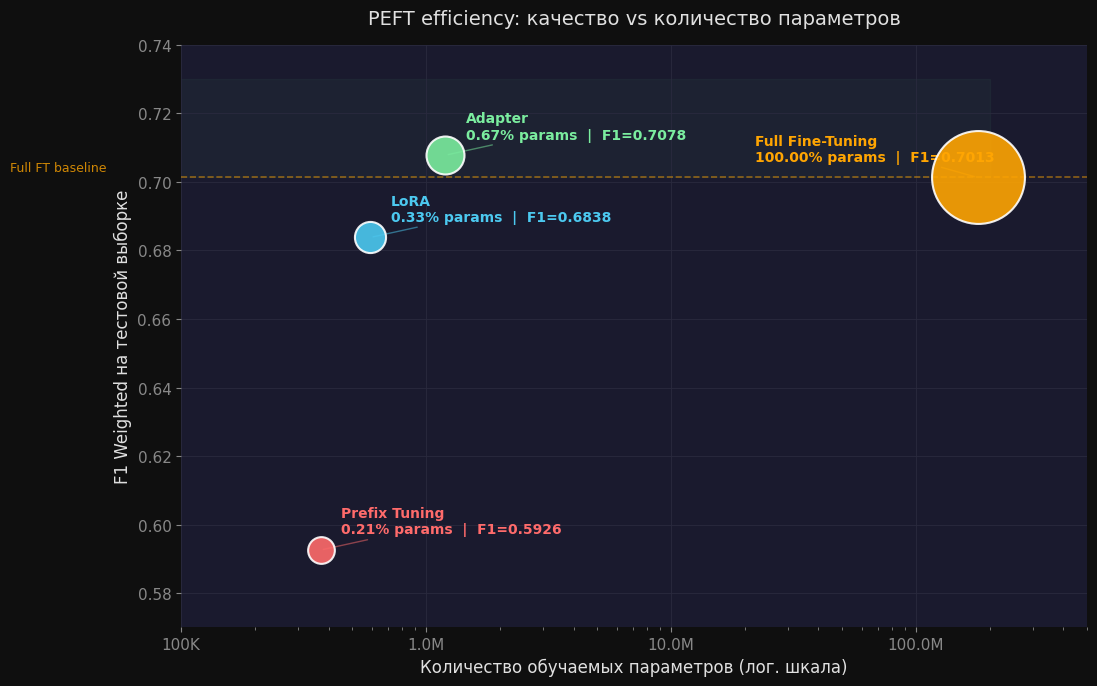

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG)

for method, color in METHOD_COLORS.items():
    params = trainable_params[method]
    f1     = results[method]['f1_weighted']
    pct    = params / trainable_params['Full Fine-Tuning'] * 100

    # Размер пузыря пропорционален log(params)
    size = (np.log10(params) - 4) ** 2.5 * 120

    ax.scatter(params, f1, s=size, color=color, zorder=5,
               edgecolors='white', linewidth=1.5, alpha=0.9)

    # Аннотация метода
    offset = (15, 12) if method != 'Full Fine-Tuning' else (-160, 12)
    ax.annotate(
        f'{method}\n{pct:.2f}% params  |  F1={f1:.4f}',
        (params, f1),
        textcoords='offset points', xytext=offset,
        fontsize=10, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color=color, alpha=0.5, lw=1)
    )

# Зона «лучше baseline» — закрашиваем
baseline_f1 = results['Full Fine-Tuning']['f1_weighted']
ax.axhline(y=baseline_f1, color=METHOD_COLORS['Full Fine-Tuning'],
           linestyle='--', linewidth=1.2, alpha=0.5)
ax.fill_between([1e4, 2e8], baseline_f1, 0.73,
                color='#7bed9f', alpha=0.04, label='Лучше baseline')
ax.text(2e4, baseline_f1 + 0.002, 'Full FT baseline', color=METHOD_COLORS['Full Fine-Tuning'],
        fontsize=9, alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Количество обучаемых параметров (лог. шкала)', fontsize=12)
ax.set_ylabel('F1 Weighted на тестовой выборке', fontsize=12)
ax.set_title('PEFT efficiency: качество vs количество параметров', fontsize=14, pad=15, color=TEXT)
ax.set_xlim(1e5, 5e8)
ax.set_ylim(0.57, 0.74)

# Красивые подписи оси X
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
))

plt.tight_layout()
plt.savefig('../experiments/plot_efficiency.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Вывод:** Adapter и LoRA находятся в «зелёной зоне» — выше baseline при минимальных параметрах. Особенно показателен Adapter: 1.2M параметров против 178M у Full FT — и лучший результат. Это ключевой вывод исследования.

## 6. F1 по классам — радарный график

Нестандартная визуализация — radar chart показывает профиль каждого метода по трём классам одновременно.

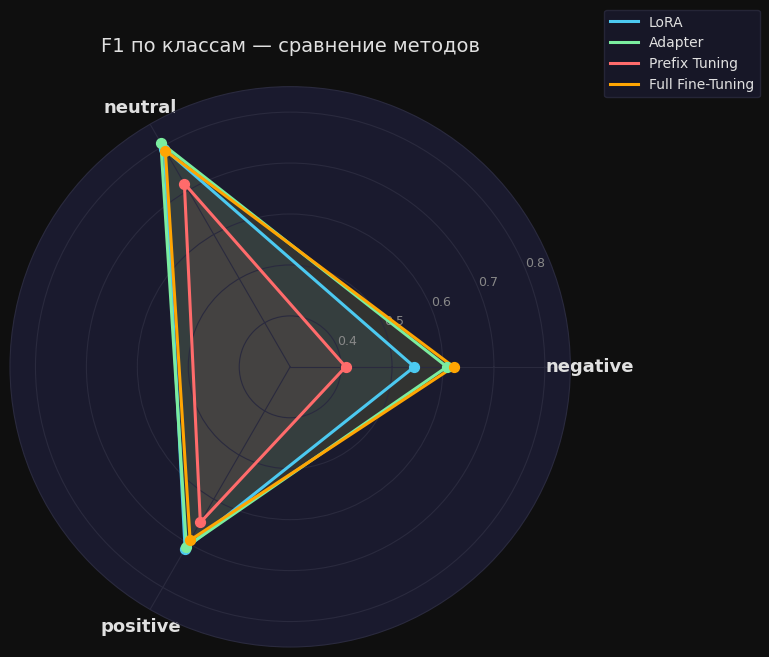

In [10]:
categories = ['negative', 'neutral', 'positive']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # замыкаем круг

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG_PANEL)

# Сетка
ax.set_ylim(0.3, 0.85)
ax.set_yticks([0.4, 0.5, 0.6, 0.7, 0.8])
ax.set_yticklabels(['0.4', '0.5', '0.6', '0.7', '0.8'], color=TEXT_DIM, fontsize=9)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color=TEXT, fontsize=13, fontweight='bold')
ax.grid(color=GRID, linewidth=0.8)
ax.spines['polar'].set_color(GRID)

for method, color in METHOD_COLORS.items():
    values = [results[method]['f1_per_class'][c] for c in categories]
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2.2, label=method)
    ax.fill(angles, values, color=color, alpha=0.08)

    # Точки на вершинах
    ax.scatter(angles[:-1], values[:-1], color=color, s=50, zorder=5)

ax.set_title('F1 по классам — сравнение методов', fontsize=14, pad=25, color=TEXT)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), framealpha=0.8, fontsize=10)

plt.tight_layout()
plt.savefig('../experiments/plot_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Вывод:** Все методы имеют схожий профиль — сильны на neutral, слабее на negative. Adapter и LoRA образуют почти идентичные профили, что говорит о схожем поведении. Prefix Tuning заметно проваливается на negative — у него самый «перекошенный» профиль.

## 7. Матрицы ошибок

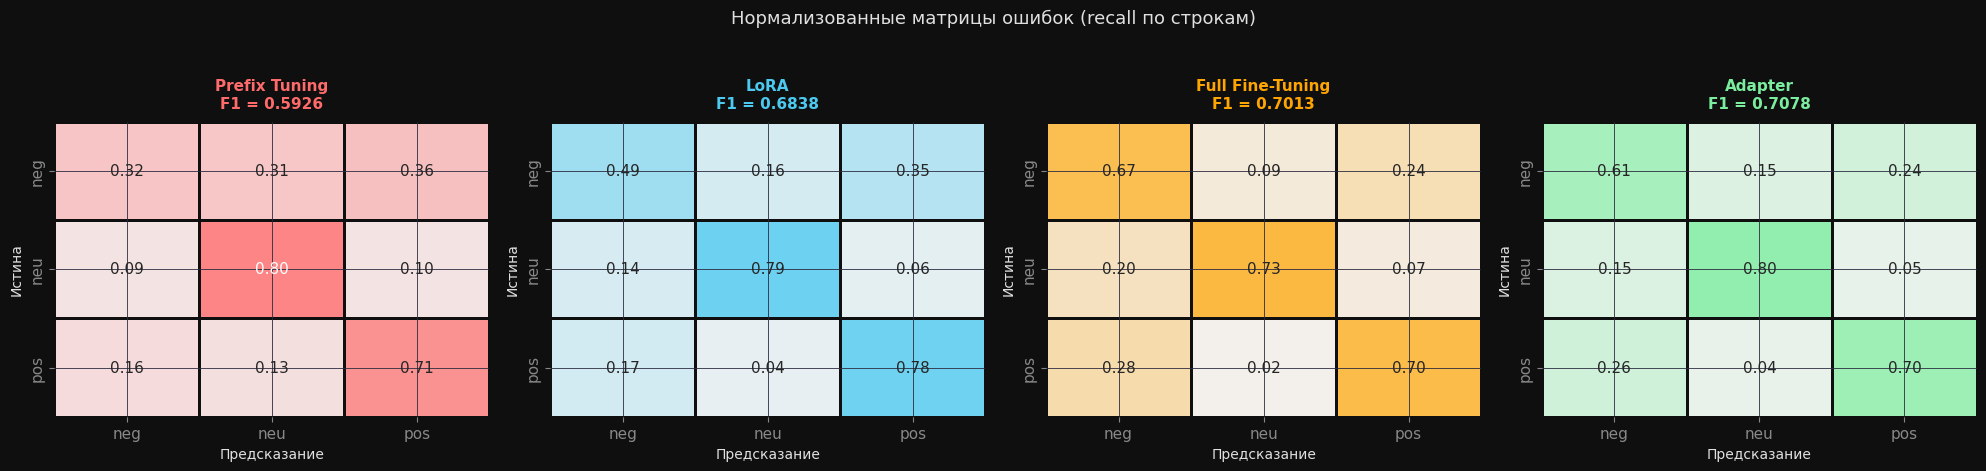

In [11]:
plot_order  = ['Prefix Tuning', 'LoRA', 'Full Fine-Tuning', 'Adapter']
class_labels = ['neg', 'neu', 'pos']

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.patch.set_facecolor(BG)

for ax, method in zip(axes, plot_order):
    cm = np.array(results[method]['confusion_matrix'], dtype=float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    cmap = sns.light_palette(METHOD_COLORS[method], as_cmap=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        xticklabels=class_labels, yticklabels=class_labels,
        cmap=cmap, ax=ax, vmin=0, vmax=1,
        linewidths=1, linecolor=BG,
        cbar=False, annot_kws={'fontsize': 11}
    )
    f1  = results[method]['f1_weighted']
    ax.set_title(f'{method}\nF1 = {f1:.4f}', fontsize=11, pad=10,
                 color=METHOD_COLORS[method], fontweight='bold')
    ax.set_xlabel('Предсказание', fontsize=10)
    ax.set_ylabel('Истина',       fontsize=10)
    ax.set_facecolor(BG_PANEL)
    for _, spine in ax.spines.items():
        spine.set_visible(False)

plt.suptitle('Нормализованные матрицы ошибок (recall по строкам)',
             fontsize=13, y=1.04, color=TEXT)
plt.tight_layout()
plt.savefig('../experiments/plot_confusion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 8. Итоговая сводка

In [12]:
print('=' * 68)
print('  ИТОГОВЫЕ РЕЗУЛЬТАТЫ — RuSentiment PEFT')
print('  Модель: DeepPavlov/rubert-base-cased | train: 21K примеров')
print('=' * 68)
print(f'{"Метод":22} {"Accuracy":>10} {"F1 W":>8} {"Params":>12} {"% от FT":>9}')
print('-' * 68)

for method in sorted(METHOD_COLORS, key=lambda m: results[m]['f1_weighted'], reverse=True):
    d      = results[method]
    params = trainable_params[method]
    pct    = params / trainable_params['Full Fine-Tuning'] * 100
    tag    = '  <-- WINNER' if method == 'Adapter' else ''
    print(f'{method:22} {d["accuracy"]:>10.4f} {d["f1_weighted"]:>8.4f}'
          f' {params:>12,} {pct:>8.2f}%{tag}')

print()
print('Ключевые выводы:')
print('  1. Adapter (0.67% params) > Full Fine-Tuning (100% params)')
print('  2. LoRA теряет лишь ~1.7% F1 vs baseline при 0.33% параметров')
print('  3. Prefix Tuning значительно отстаёт, особенно на классе negative')
print('  4. PEFT методы — жизнеспособная альтернатива полному файнтюнингу')
print('=' * 68)

  ИТОГОВЫЕ РЕЗУЛЬТАТЫ — RuSentiment PEFT
  Модель: DeepPavlov/rubert-base-cased | train: 21K примеров
Метод                    Accuracy     F1 W       Params   % от FT
--------------------------------------------------------------------
Adapter                    0.7073   0.7078    1,200,000     0.67%  <-- WINNER
Full Fine-Tuning           0.6970   0.7013  178,447,878   100.00%
LoRA                       0.6891   0.6838      592,131     0.33%
Prefix Tuning              0.6122   0.5926      370,947     0.21%

Ключевые выводы:
  1. Adapter (0.67% params) > Full Fine-Tuning (100% params)
  2. LoRA теряет лишь ~1.7% F1 vs baseline при 0.33% параметров
  3. Prefix Tuning значительно отстаёт, особенно на классе negative
  4. PEFT методы — жизнеспособная альтернатива полному файнтюнингу
